In [3]:
%pip install selenium webdriver-manager pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time
import pandas as pd

In [5]:
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver  = webdriver.Chrome(service = Service(ChromeDriverManager().install()), options=options)


In [6]:
url = "https://www.youtube.com/watch?v=HhesaQXLuRY"
driver.get(url)
time.sleep(5)

In [7]:
driver.execute_script("window.scrollTo(0,800);")
time.sleep(3)


In [8]:
# scroll mulitple times to load more comments
for i in range(10):
    driver.execute_script("window.scrollBy(0,1000);")
    time.sleep(3)

In [9]:
# extract comments
comments = driver.find_elements(By.XPATH, '//*[@id="content-text"]')

In [10]:
comment_list = []
for comment in comments:
    comment_list.append(comment.text)


In [11]:
driver.quit()
df = pd.DataFrame(comment_list, columns=["Comment"])
df.head()

,Comment
0,If you haven't seen breaking bad your eyes are...
1,"Hank : "" Get a little excitement in your life""..."
2,You know the business and i know the chemistry..
3,"I can't wait for this to come out, Better Call..."
4,"If you haven't seen this, you've literally mis..."


In [12]:
print("Total comments Collected: ", len(df))
df.tail(10)

Total comments Collected:  80


,Comment
70,"""Bring a little excitement in your life""\nWron..."
71,Walt to Jessi : “you know the business”\n\nJes...
72,Greatest show ever made and no one other show ...
73,I think it’s never to late! Saison 1 Ep 1! Let...
74,I am so glad I watched this fuckin awsome show...
75,Good old days.......When TV shows was much mor...
76,Watching this after knowing how it will end ju...
77,I wish i get memory loss so i can rewatch this...
78,விடாமுயற்சி
79,I've started watching this yesterday and finis...


In [13]:
%pip install nltk textblob wordcloud matplotlib


Note: you may need to restart the kernel to use updated packages.


In [14]:
import nltk
nltk.download('stopwords')
import re
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jenis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [16]:
df["Cleaned"] = df["Comment"].apply(clean_text)
df.head(5)


,Comment,Cleaned
0,If you haven't seen breaking bad your eyes are...,havent seen breaking bad eyes still virgin
1,"Hank : "" Get a little excitement in your life""...",hank get little excitement life worst advice e...
2,You know the business and i know the chemistry..,know business know chemistry
3,"I can't wait for this to come out, Better Call...",cant wait come better call saul masterpiece sh...
4,"If you haven't seen this, you've literally mis...",havent seen youve literally missed greatest tv...


In [17]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [20]:
df["sentiment"] = df["Cleaned"].apply(get_sentiment)
df.head()

,Comment,Cleaned,sentiment
0,If you haven't seen breaking bad your eyes are...,havent seen breaking bad eyes still virgin,Negative
1,"Hank : "" Get a little excitement in your life""...",hank get little excitement life worst advice e...,Negative
2,You know the business and i know the chemistry..,know business know chemistry,Neutral
3,"I can't wait for this to come out, Better Call...",cant wait come better call saul masterpiece sh...,Positive
4,"If you haven't seen this, you've literally mis...",havent seen youve literally missed greatest tv...,Positive


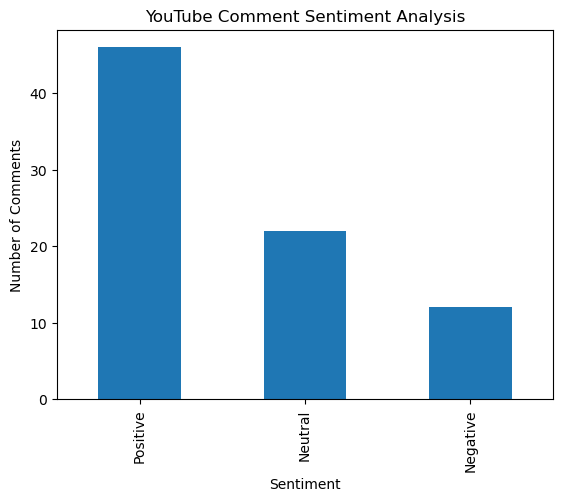

In [22]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()
sentiment_counts.plot(kind="bar")
plt.title("YouTube Comment Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

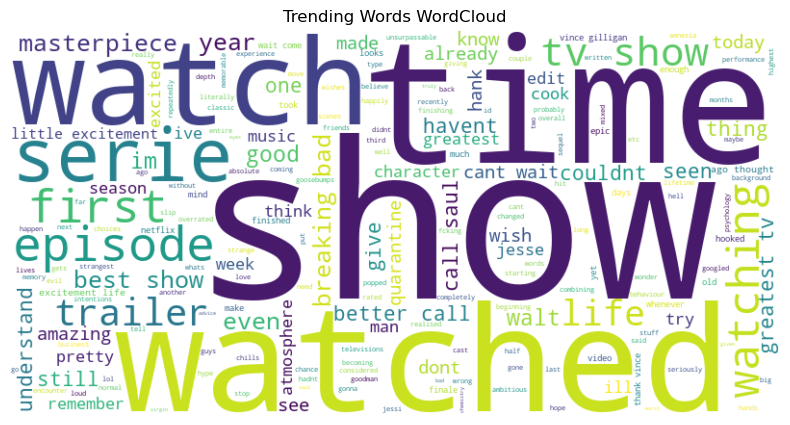

In [25]:
from wordcloud import WordCloud

all_words = " ".join(df["Cleaned"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Words WordCloud")
plt.show()